<a href="https://colab.research.google.com/github/refianP13/Data-Analyst/blob/main/Copy_of_%5BMENTOR_VER%5D_SESI_12_telco_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn — Exploratory Data Analysis

**Tujuan notebook ini:** membedah data pelanggan telekomunikasi untuk memahami pola *churn* (pelanggan berhenti berlangganan), menggunakan `pandas` untuk data cleansing & preparation, serta `matplotlib` dan `seaborn` untuk visualisasi.

**Struktur:**
1. Import Library & Load Data
2. Data Understanding (struktur, tipe data, ukuran)
3. Data Cleansing & Preparation
4. Univariate Analysis (distribusi tiap variabel)
5. Bivariate Analysis terhadap Churn
6. Multivariate Analysis & Korelasi
7. Ringkasan Insight & Rekomendasi Bisnis

> Catatan buat yang baru belajar: setiap kali kita bikin plot, akan ada sel markdown **"Insight"** setelahnya. Jangan cuma baca grafiknya — baca juga cara kita menyimpulkannya, karena itu skill yang lebih penting daripada hafal syntax `seaborn`.

## 1. Import Library & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

# Setting tampilan visual biar konsisten di seluruh notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/sample_data/telco_customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Kenapa `pd.set_option('display.max_columns', None)`?**
Dataset ini punya 21 kolom. Tanpa setting ini, pandas akan memotong tampilan kolom di tengah (menampilkan `...`) supaya muat di layar. Untuk eksplorasi awal, kita justru ingin melihat *semua* kolom sekaligus.

## 2. Data Understanding

In [ ]:
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
df.info()

Jumlah baris: 7043
Jumlah kolom: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

**Insight awal [Certain]:**
- Dataset berisi 7043 baris (pelanggan) dan 21 kolom.
- Perhatikan `TotalCharges` bertipe `object` (string), padahal secara semantik dia harus numerik (total biaya dalam mata uang). Ini adalah *red flag* pertama — sering terjadi karena ada karakter tersembunyi seperti spasi kosong di beberapa baris.
- `SeniorCitizen` bertipe `int64` (0/1) sementara kolom biner lain seperti `Partner`, `Dependents` bertipe string `"Yes"/"No"`. Tidak konsisten — perlu diseragamkan nanti kalau mau dipakai untuk modeling.

In [ ]:
# Cek statistik deskriptif untuk kolom numerik
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Cek statistik untuk kolom kategorikal
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


**Insight [Certain]:** Kolom `customerID` punya 7043 nilai unik (sama dengan jumlah baris) — konfirmasi bahwa ini adalah primary key, bukan fitur analisis. Kolom ini akan kita drop nanti karena tidak informatif untuk analisis pola.

## 3. Data Cleansing & Preparation

### 3.1 Cek Missing Value (yang kelihatan)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Jangan langsung percaya hasil di atas.** `isnull()` hanya mendeteksi `NaN`/`None` — tidak mendeteksi string kosong `""` atau `" "` yang menyamar sebagai data valid. Ini kesalahan pemula yang paling umum: mengira data "bersih" hanya karena `isnull().sum()` menunjukkan nol.

Mari kita cek `TotalCharges` lebih dalam, karena tadi kita curigai dia harusnya numerik.

In [ ]:
# Coba convert ke numerik, paksa yang gagal jadi NaN supaya ketahuan
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Jumlah nilai yang gagal dikonversi: {total_charges_numeric.isnull().sum()}")

# Tampilkan baris-baris bermasalah
filter_df = df[total_charges_numeric.isnull()]
display(filter_df)
display(filter_df[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Jumlah nilai yang gagal dikonversi: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Insight [Certain]:** Ada 11 baris dengan `TotalCharges` berupa string kosong (`" "`), bukan `NaN`. Semua baris ini punya `tenure = 0`, artinya mereka pelanggan yang baru saja mendaftar dan belum pernah ditagih — jadi secara bisnis masuk akal `TotalCharges`-nya "belum ada" alih-alih hilang secara acak.

**Keputusan cleansing [Likely]:** Karena hanya 11 dari 7043 baris (0.16%), dan penyebabnya jelas (`tenure=0`), pilihan paling aman adalah mengisi nilainya dengan 0 (bukan menghapus baris, karena kita masih ingin tahu perilaku pelanggan baru terhadap churn).

In [ ]:
# Konversi TotalCharges ke numerik, isi yang kosong dengan 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verifikasi
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum())
display(df.iloc[488:754, :])

float64
0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.00,No
489,8372-JUXUI,Male,0,No,Yes,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.35,74.35,Yes
490,3552-CTCYF,Male,0,Yes,Yes,63,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),104.80,6597.25,No
491,6778-YSNIH,Female,0,No,No,2,Yes,No,DSL,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,59.00,114.15,No
492,0388-EOPEX,Female,0,Yes,No,2,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.40,139.40,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,8405-IGQFX,Female,0,No,No,63,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,No,One year,Yes,Credit card (automatic),90.05,5817.00,No
750,8224-IVVPA,Female,0,No,No,27,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,56.70,1652.95,No
751,9477-LGWQI,Male,0,Yes,Yes,70,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),80.15,5600.15,No
752,1410-RSCMR,Male,0,Yes,Yes,7,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Month-to-month,Yes,Credit card (automatic),71.35,515.75,No


### 3.2 Cek Duplikasi

In [ ]:
print(f"Jumlah baris duplikat (full row): {df.duplicated().sum()}")
print(f"Jumlah customerID duplikat: {df['customerID'].duplicated().sum()}")

Jumlah baris duplikat (full row): 0
Jumlah customerID duplikat: 0


**Insight [Certain]:** Tidak ada duplikasi. Aman lanjut.

### 3.3 Standardisasi Kolom Kategorikal

Beberapa kolom seperti `MultipleLines`, `OnlineSecurity`, dll punya value `"No internet service"` atau `"No phone service"` selain `"Yes"/"No"`. Ini bukan error, tapi perlu kita sadari karena akan mempengaruhi cara kita membaca grafik nanti.

In [ ]:
cols_with_service_dependency = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_with_service_dependency:
    print(f"{col}: {df[col].unique()}")

MultipleLines: ['No phone service' 'No' 'Yes']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']


In [ ]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

**Insight [Certain]:** Value `"No internet service"` muncul di 6 kolom sekaligus — ini bukan variasi acak, tapi konsekuensi logis dari pelanggan yang tidak berlangganan `InternetService` sama sekali. Artinya kolom-kolom ini **tidak independen** satu sama lain; mereka semua "anak" dari `InternetService`. Penting dipahami sebelum masuk ke feature engineering / modeling, supaya tidak salah interpretasi seolah itu kategori ketiga yang berdiri sendiri.

### 3.4 Drop kolom yang tidak informatif untuk analisis pola

In [ ]:
df_clean = df.drop(columns=['customerID'])
df_clean.shape

(7043, 20)

### 3.5 Membuat kolom bantu untuk analisis

`tenure` (dalam bulan) sulit dibaca sebagai grafik distribusi mentah. Kita bikin `tenure_group` supaya lebih mudah dibaca sebagai kategori bisnis (pelanggan baru vs lama).

In [ ]:
df_clean.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
def tenure_group(t):
    if t <= 12:
        return '0-1 tahun'
    elif t <= 24:
        return '1-2 tahun'
    elif t <= 48:
        return '2-4 tahun'
    else:
        return '4+ tahun'

df_clean['tenure_group'] = df_clean['tenure'].apply(tenure_group)
df_clean['tenure_group'] = pd.Categorical(df_clean['tenure_group'],
                                            categories=['0-1 tahun', '1-2 tahun', '2-4 tahun', '4+ tahun'],
                                            ordered=True)
df_clean[['tenure', 'tenure_group']].head()

,tenure,tenure_group
0,1,0-1 tahun
1,34,2-4 tahun
2,2,0-1 tahun
3,45,2-4 tahun
4,2,0-1 tahun


**Kenapa pakai `pd.Categorical` dengan `ordered=True`?**
Tanpa ini, saat kita plot dengan seaborn, urutan kategori di sumbu-x bisa acak (misal "4+ tahun" muncul sebelum "0-1 tahun") karena secara default diurutkan alfabetis. Dengan `Categorical` yang eksplisit ordered, urutan tampilan mengikuti logika bisnis kita.

## 4. Univariate Analysis

### 4.1 Distribusi Target: Churn

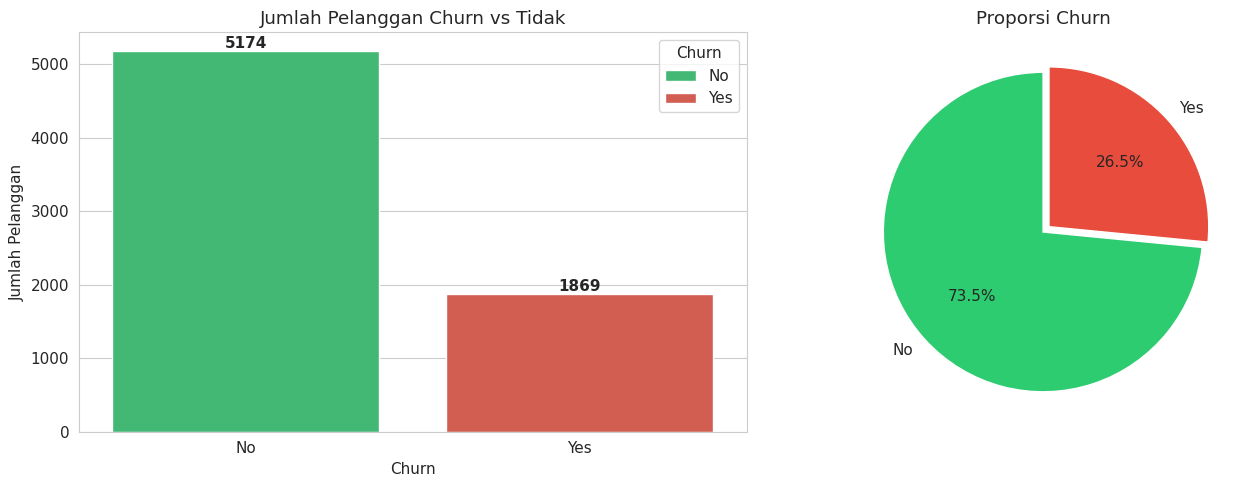

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart jumlah
churn_counts = df_clean['Churn'].value_counts()
sns.barplot(x=churn_counts.index, y=churn_counts.values, hue=churn_counts.index,
            palette=['#2ecc71', '#e74c3c'], ax=axes[0], legend=True)
axes[0].set_title('Jumlah Pelanggan Churn vs Tidak')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Jumlah Pelanggan')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

# Pie chart proporsi
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Proporsi Churn')

plt.tight_layout()
plt.show()

**Insight [Certain]:** 26.5% pelanggan (1869 dari 7043) melakukan churn. Ini adalah kasus **imbalanced class** — rasio sekitar 73:27. Poin ini penting dicatat sekarang karena kalau nanti dataset ini dipakai untuk *predictive modeling*, akurasi sederhana bisa menyesatkan (model yang selalu memprediksi "No" saja sudah dapat akurasi 73%). Untuk sesi hari ini kita fokus EDA dulu, tapi ini nilai edukatif yang wajib disampaikan ke peserta.

### 4.2 Distribusi Variabel Numerik

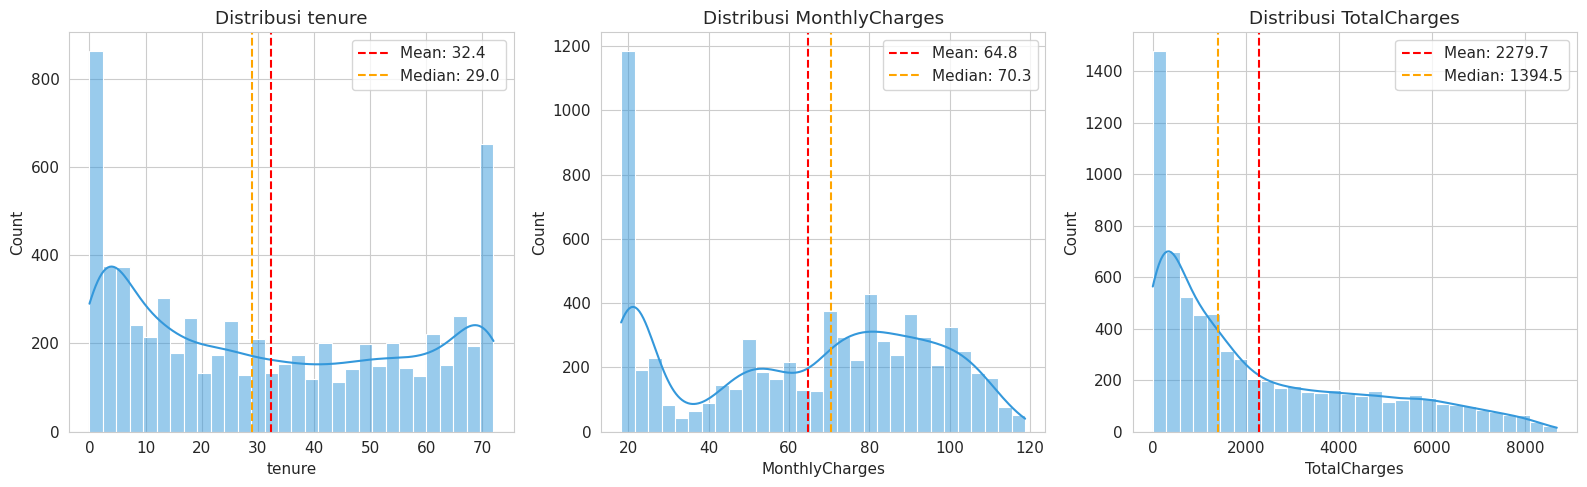

In [ ]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='#3498db', bins=30)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[col].mean():.1f}')
    axes[i].axvline(df_clean[col].median(), color='orange', linestyle='--', label=f'Median: {df_clean[col].median():.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

**Insight [Likely]:**
- `tenure` punya distribusi bimodal — banyak pelanggan sangat baru (dekat 0 bulan) dan banyak juga yang sangat loyal (dekat 72 bulan). Pola dua puncak seperti ini biasanya menandakan dua populasi berbeda tercampur (pelanggan baru yang belum teruji loyalitasnya, vs pelanggan lama yang sudah "bertahan").
- `MonthlyCharges` juga sedikit bimodal, kemungkinan terkait jenis layanan (yang pakai internet fiber cenderung bayar lebih mahal daripada yang tidak).
- `TotalCharges` right-skewed (miring ke kanan) — wajar karena ini akumulasi dari `tenure x MonthlyCharges`, jadi pelanggan lama otomatis punya total lebih besar.

### 4.3 Distribusi Variabel Demografis & Kontrak

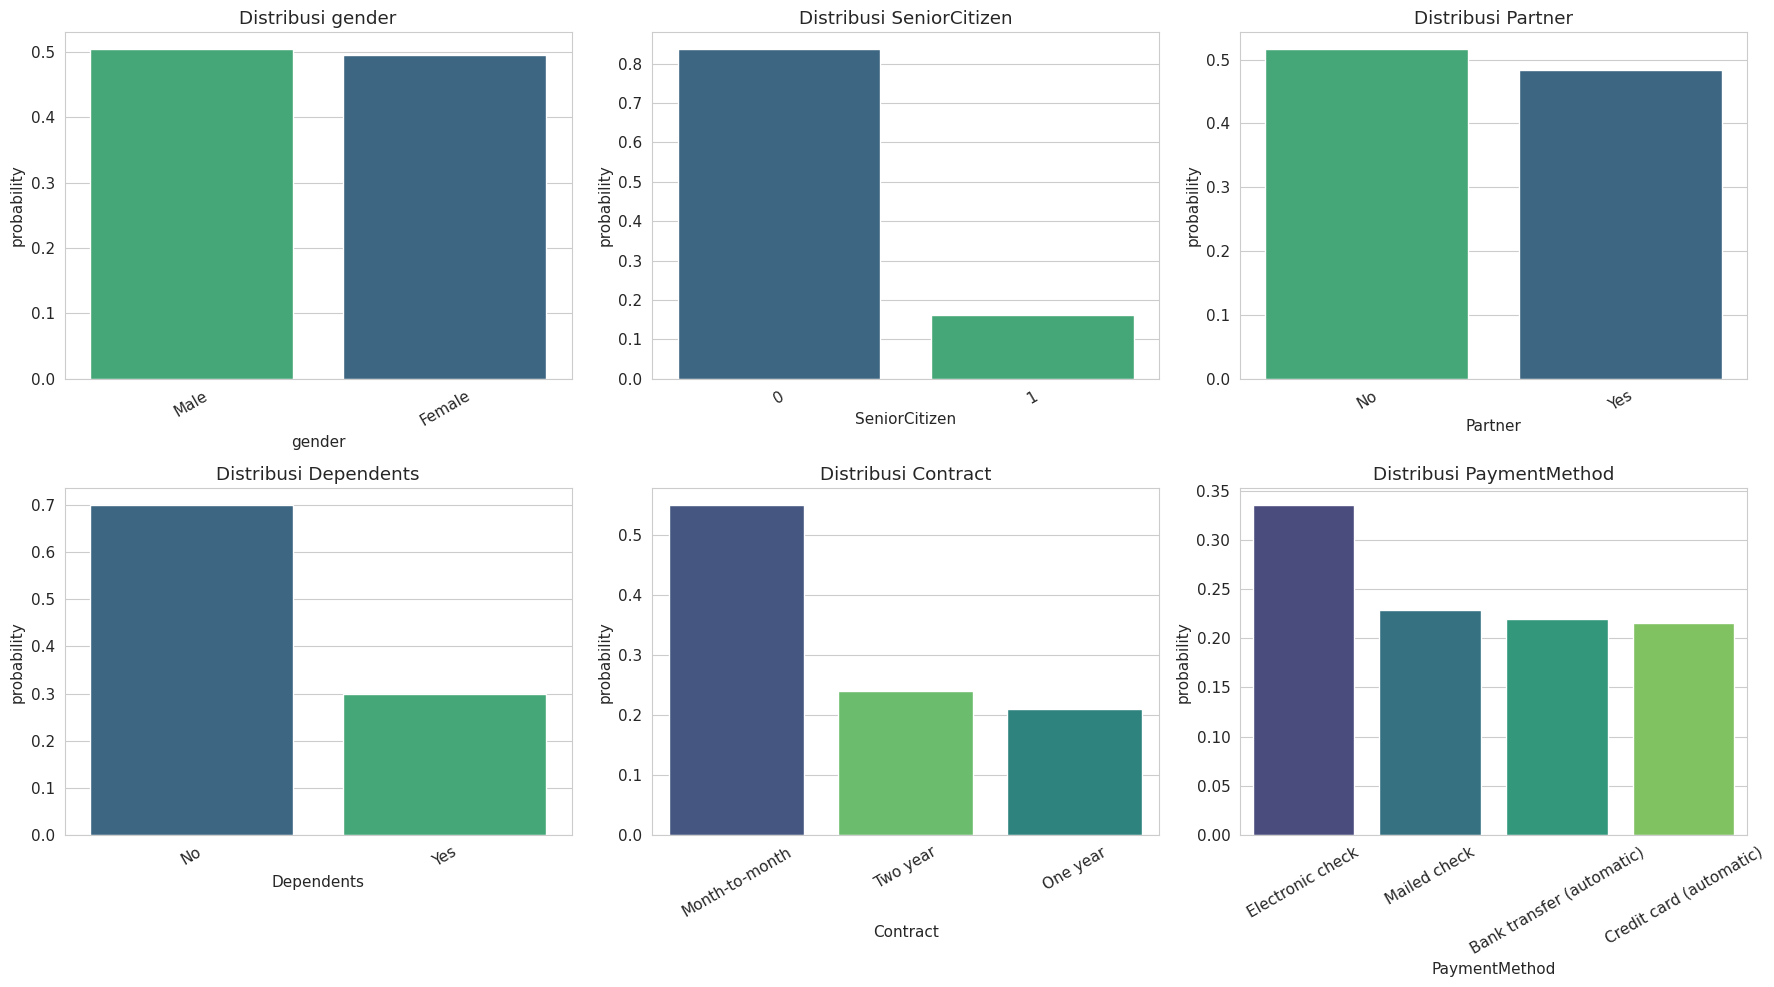

In [ ]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df_clean[col].value_counts(normalize=True).index
    sns.countplot(data=df_clean, x=col, hue=col, order=order, palette='viridis', ax=axes[i], legend=False, stat='probability')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Insight [Likely]:**
- Gender cukup seimbang (~50:50) — bukan faktor pembeda yang menarik untuk churn.
- Hanya ~16% pelanggan adalah Senior Citizen — mayoritas basis pelanggan usia non-senior.
- `Contract` didominasi oleh `Month-to-month` — ini penting karena kontrak bulanan biasanya punya barrier keluar paling rendah, jadi layak dicurigai berkorelasi kuat dengan churn (akan kita cek di bagian bivariate).
- `Electronic check` adalah metode pembayaran paling umum, diikuti mailed check dan pembayaran otomatis.

## 5. Bivariate Analysis: Hubungan dengan Churn

### 5.1 Churn berdasarkan Tipe Kontrak

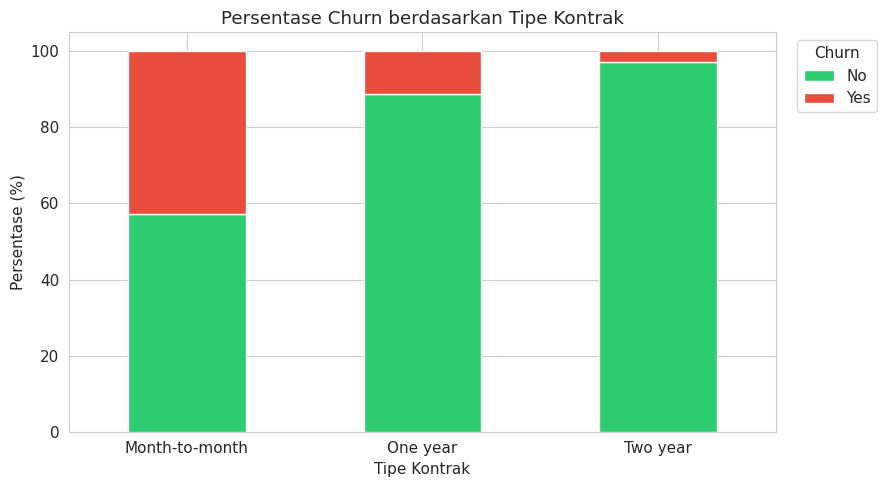

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [ ]:
plt.figure(figsize=(9, 5))
contract_churn = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=plt.gca())
plt.title('Persentase Churn berdasarkan Tipe Kontrak')
plt.ylabel('Persentase (%)')
plt.xlabel('Tipe Kontrak')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

print(contract_churn)

**Insight [Certain]:** Ini salah satu temuan paling kuat di dataset ini. Pelanggan `Month-to-month` churn sekitar 42%, sementara `One year` sekitar 11% dan `Two year` di bawah 3%. Semakin panjang komitmen kontrak, semakin rendah churn-nya — pola yang sangat masuk akal secara bisnis (biaya keluar dari kontrak panjang lebih tinggi, secara psikologis maupun finansial).

**Implikasi bisnis [Likely]:** strategi retensi paling efisien kemungkinan adalah mendorong migrasi dari kontrak bulanan ke kontrak tahunan, misalnya lewat diskon loyalitas.

### 5.2 Churn berdasarkan Tenure Group

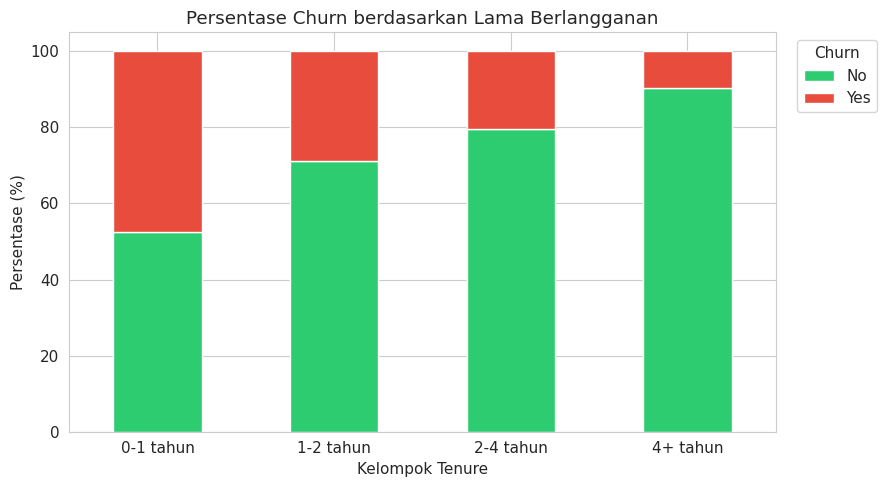

In [ ]:
plt.figure(figsize=(9, 5))
tenure_churn = pd.crosstab(df_clean['tenure_group'], df_clean['Churn'], normalize='index') * 100
tenure_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=plt.gca())
plt.title('Persentase Churn berdasarkan Lama Berlangganan')
plt.ylabel('Persentase (%)')
plt.xlabel('Kelompok Tenure')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**Insight [Certain]:** Churn tertinggi ada di kelompok pelanggan baru (0-1 tahun), dan terus menurun seiring bertambahnya lama berlangganan. Ini konsisten dengan temuan distribusi bimodal `tenure` sebelumnya — pelanggan yang berhasil "bertahan" melewati fase awal cenderung jadi loyal jangka panjang. Ini mengindikasikan **periode kritis retensi ada di tahun pertama**, bukan tersebar merata di seluruh siklus hidup pelanggan.

### 5.3 Churn berdasarkan Monthly Charges

2.7066456068884154e-60
Column MonthlyCharges has strong relationship with Churn.


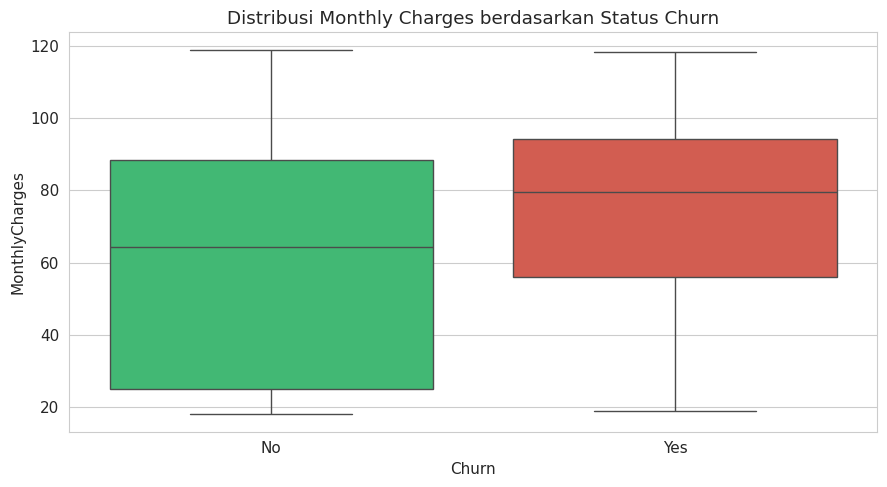

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


In [ ]:
data1 = df_clean[df_clean['Churn']=='No']['MonthlyCharges']
data2 = df_clean[df_clean['Churn']=='Yes']['MonthlyCharges']

stat, p = stats.ttest_ind(a=data1, b=data2, alternative='two-sided')
print(p)
if(p<0.05):
    print('Column MonthlyCharges has strong relationship with Churn.')
else:
    print('Column MonthlyCharges has weak relationship with Churn.')

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', hue='Churn',
            palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribusi Monthly Charges berdasarkan Status Churn')
plt.tight_layout()
plt.show()

print(df_clean.groupby('Churn', observed=True)['MonthlyCharges'].describe())

**Insight [Likely]:** Median `MonthlyCharges` pelanggan yang churn lebih tinggi dibanding yang tidak churn. Ini sedikit kontra-intuitif kalau dipikir sepintas (biasanya kita kira harga murah = lebih loyal), tapi masuk akal kalau dikombinasikan dengan insight berikutnya soal jenis layanan internet — pelanggan Fiber optic biasanya bayar lebih mahal DAN churn lebih tinggi, kemungkinan karena ekspektasi kualitas layanan yang tidak terpenuhi relatif terhadap harga premium yang dibayar.

### 5.4 Churn berdasarkan Jenis Internet Service

Column InternetService has strong relationship with Churn label


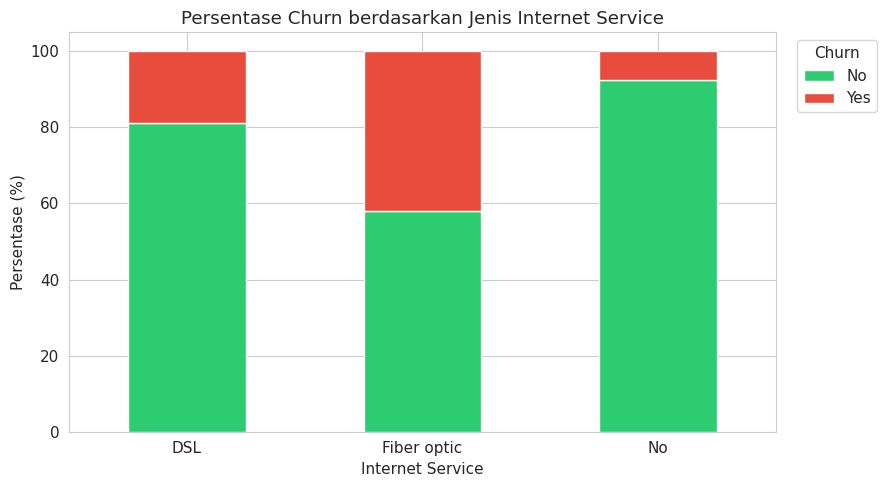

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [ ]:
plt.figure(figsize=(9, 5))
internet_churn = pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index') * 100
chi2, p, dof, expected = chi2_contingency(internet_churn)
if(p < 0.05):
  chi2_res = 'Column InternetService has strong relationship with Churn label'
else:
  chi2_res = 'Column InternetService has no relationship with Churn label'
print(chi2_res)
internet_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=plt.gca())
plt.title('Persentase Churn berdasarkan Jenis Internet Service')
plt.ylabel('Persentase (%)')
plt.xlabel('Internet Service')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

print(internet_churn)

**Insight [Certain]:** Pelanggan `Fiber optic` churn paling tinggi (~42%), jauh di atas `DSL` (~19%) dan `No internet service` (~7%). Ini menguatkan dugaan di poin sebelumnya — kombinasi harga premium + churn tinggi di segmen Fiber optic adalah sinyal kuat adanya *gap* antara ekspektasi dan realita layanan (misalnya masalah kestabilan koneksi, customer support, atau harga yang dirasa tidak sepadan).

**Catatan metodologis [Guessing]:** dataset ini tidak punya kolom kepuasan pelanggan atau keluhan, jadi hipotesis "gap ekspektasi vs realita" ini adalah dugaan yang masuk akal berdasarkan pola data, bukan fakta yang terverifikasi langsung dari data.

### 5.5 Churn berdasarkan Layanan Pendukung (Add-on Services)

Column Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194 has strong relationship with Churn label
Column Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494 has strong relationship with Churn label
Column Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064 has strong relationship with Churn label
Column Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341 has stron

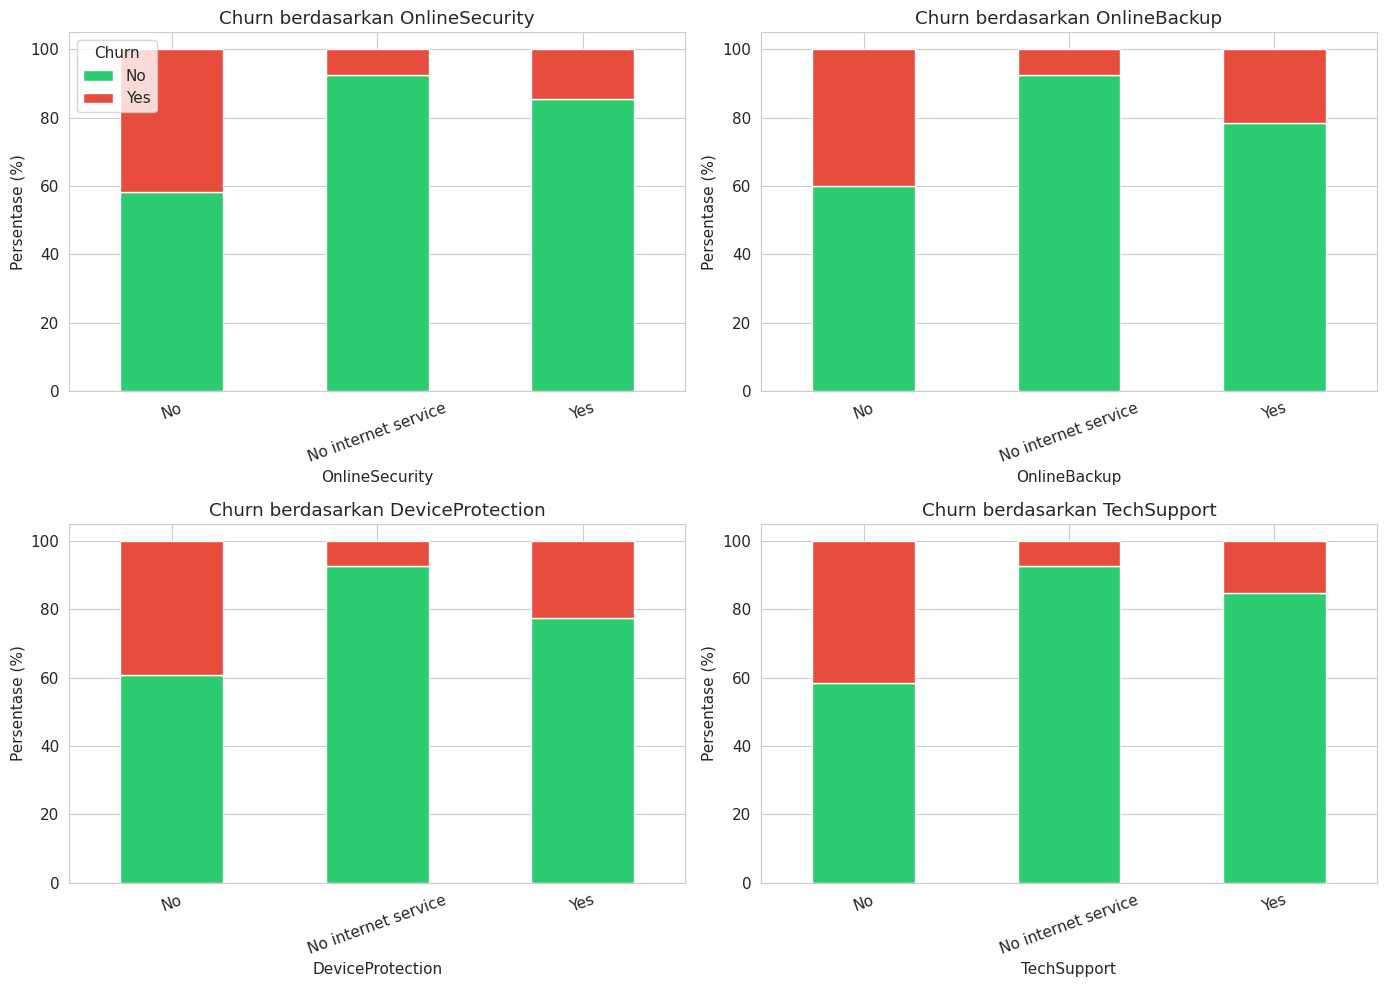

In [ ]:
addon_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(addon_services):
    ct = pd.crosstab(df_clean[col], df_clean['Churn'], normalize='index') * 100
    chi2, p, dof, expected = chi2_contingency(ct)
    if(p < 0.05):
      chi2_res = f'Column {ct} has strong relationship with Churn label'
    else:
      chi2_res = f'Column {ct} has no relationship with Churn label'
    print(chi2_res)
    ct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[i], legend=(i==0))
    axes[i].set_title(f'Churn berdasarkan {col}')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Insight [Certain]:** Pola konsisten di keempat layanan: pelanggan yang **tidak** berlangganan `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, atau `TechSupport` punya churn jauh lebih tinggi dibanding yang berlangganan. Khususnya `TechSupport` dan `OnlineSecurity` menunjukkan gap paling besar.

**Implikasi bisnis [Likely]:** layanan add-on ini kemungkinan berfungsi sebagai "perekat" yang meningkatkan switching cost dan rasa aman pelanggan. Menawarkan bundling add-on ini secara gratis/diskon di awal langganan bisa jadi strategi retensi yang layak diuji (misalnya lewat A/B test), bukan sekadar upsell.

### 5.6 Churn berdasarkan Payment Method

Column PaymentMethod has strong relationship with Churn label


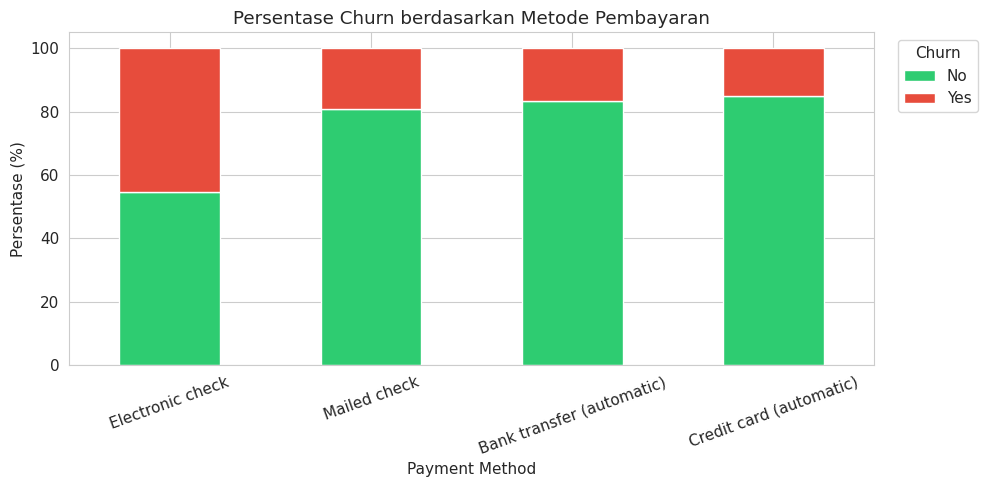

In [ ]:
plt.figure(figsize=(10, 5))
payment_churn = pd.crosstab(df_clean['PaymentMethod'], df_clean['Churn'], normalize='index') * 100
payment_churn = payment_churn.sort_values('Yes', ascending=False)
chi2, p, dof, expected = chi2_contingency(payment_churn)
if(p < 0.05):
  print(f'Column PaymentMethod has strong relationship with Churn label')
else:
  print(f'Column PaymentMethod has no relationship with Churn label')
payment_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=plt.gca())
plt.title('Persentase Churn berdasarkan Metode Pembayaran')
plt.ylabel('Persentase (%)')
plt.xlabel('Payment Method')
plt.xticks(rotation=20)
plt.legend(title='Churn', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**Insight [Certain]:** `Electronic check` punya churn tertinggi (~45%), jauh di atas metode pembayaran otomatis (`Bank transfer (automatic)`, `Credit card (automatic)`) yang sekitar 15-16%. Metode pembayaran manual berkorelasi dengan gesekan (*friction*) yang lebih besar dalam hubungan pelanggan-perusahaan, dan mungkin juga proxy dari segmen pelanggan yang kurang "terikat" secara administratif.

## 6. Multivariate Analysis & Korelasi

### 6.1 Correlation Heatmap (variabel numerik)

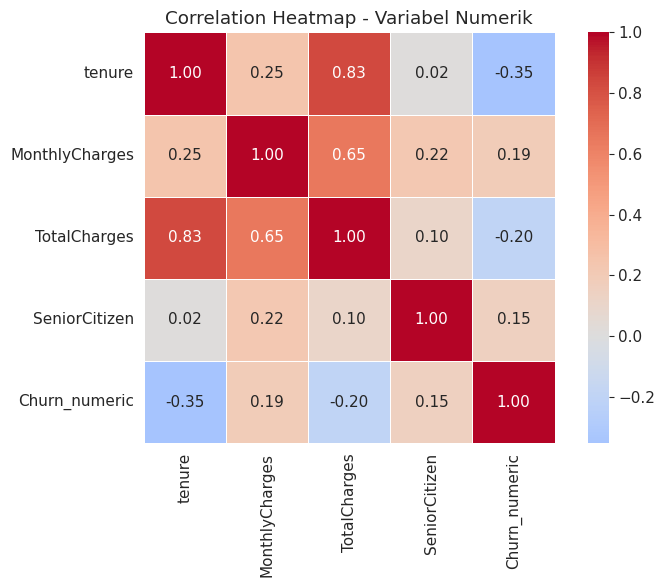

In [ ]:
# Encode Churn jadi numerik untuk dimasukkan ke correlation matrix
df_corr = df_clean.copy()
df_corr['Churn_numeric'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Variabel Numerik')
plt.tight_layout()
plt.show()

# VIF

**Insight [Certain]:**
- `tenure` berkorelasi negatif cukup kuat dengan `Churn_numeric` (sekitar -0.35) — konsisten dengan temuan di bagian 5.2.
- `MonthlyCharges` berkorelasi positif lemah-sedang dengan churn (sekitar 0.19) — konsisten dengan 5.3.
- `TotalCharges` berkorelasi negatif dengan churn, tapi ini **kemungkinan besar korelasi semu (spurious)** [Likely] karena `TotalCharges` sangat dipengaruhi oleh `tenure` (pelanggan lama otomatis totalnya besar). Jangan buru-buru menyimpulkan `TotalCharges` sebagai *driver* independen churn — perlu dicek dengan mengontrol variabel `tenure`.
- `tenure` dan `TotalCharges` berkorelasi sangat tinggi (>0.8 biasanya di dataset ini) — ini sinyal **multikolinearitas** yang penting dicatat kalau nanti lanjut ke tahap modeling.

### 6.2 Interaksi Tenure x MonthlyCharges terhadap Churn

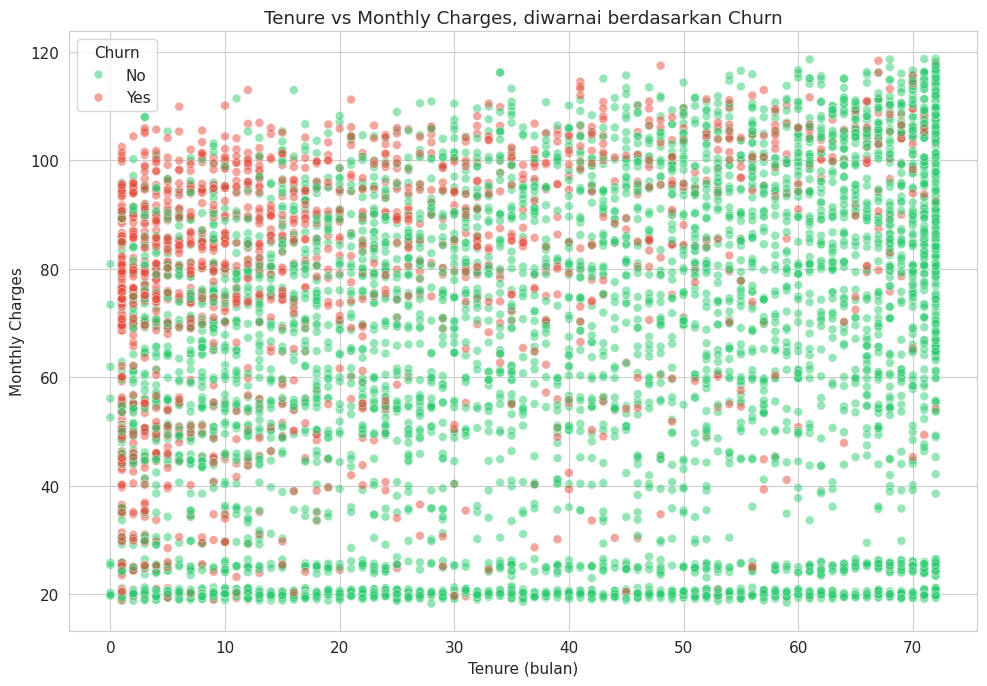

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_clean, x='tenure', y='MonthlyCharges', hue='Churn',
                 palette=['#2ecc71', '#e74c3c'], alpha=0.5, s=40)
plt.title('Tenure vs Monthly Charges, diwarnai berdasarkan Churn')
plt.xlabel('Tenure (bulan)')
plt.ylabel('Monthly Charges')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**Insight [Likely]:** Titik-titik merah (churn) menumpuk paling padat di area tenure rendah DAN monthly charges tinggi (kiri-atas grafik). Ini adalah "zona bahaya" gabungan — pelanggan baru yang bayar mahal adalah segmen paling rentan. Sebaliknya, titik hijau (tidak churn) menyebar lebih merata ke tenure tinggi. Kombinasi dua variabel ini lebih informatif daripada melihat masing-masing secara terpisah.

### 6.3 Contract x InternetService terhadap Churn Rate

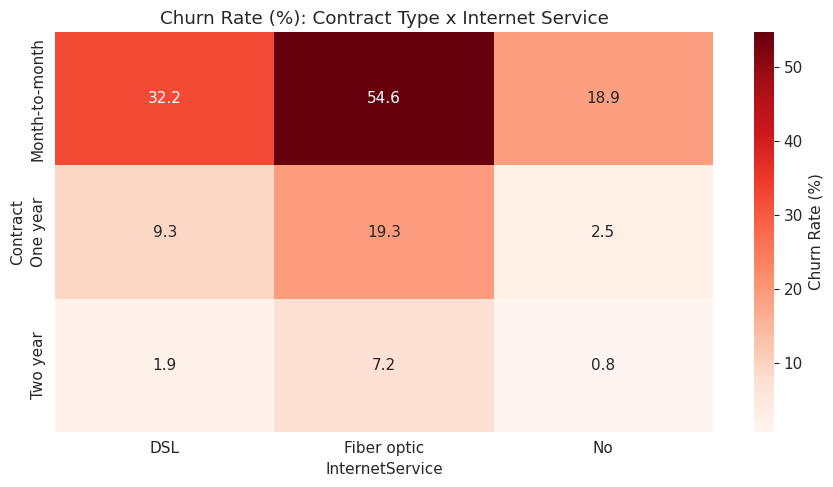

In [ ]:
pivot = df_clean.pivot_table(values='Churn', index='Contract', columns='InternetService',
                               aggfunc=lambda x: (x == 'Yes').mean() * 100, observed=True)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%): Contract Type x Internet Service')
plt.tight_layout()
plt.show()

**Insight [Certain]:** Segmen paling berisiko adalah kombinasi `Month-to-month` + `Fiber optic` dengan churn rate tertinggi di seluruh matriks (biasanya di atas 50%). Sebaliknya, `Two year` + `No internet service`/`DSL` punya churn mendekati 0%. Ini adalah contoh bagus kenapa analisis univariate/bivariate saja tidak cukup — efek dua variabel yang digabung bisa jauh lebih ekstrem daripada masing-masing secara terpisah (*interaction effect*).

Buat sesi mengajar: ini titik bagus untuk menjelaskan konsep *interaction effect* ke peserta — dua variabel yang secara individu "sedang" korelasinya bisa saling memperkuat ketika dikombinasikan.

## 7. Ringkasan Insight & Rekomendasi Bisnis

### Ringkasan Temuan Utama

1. **[Certain]** Churn rate keseluruhan 26.5% — imbalanced class, catatan penting kalau lanjut ke modeling.
2. **[Certain]** Tipe kontrak adalah prediktor terkuat: Month-to-month churn ~42% vs Two year <3%.
3. **[Certain]** Tahun pertama adalah periode kritis retensi — churn tertinggi terjadi di pelanggan dengan tenure rendah.
4. **[Certain]** Segmen Fiber optic membayar lebih mahal DAN churn lebih tinggi — indikasi gap ekspektasi-realita layanan.
5. **[Certain]** Ketiadaan layanan add-on (TechSupport, OnlineSecurity, dll) berkorelasi dengan churn lebih tinggi.
6. **[Certain]** Electronic check adalah metode pembayaran dengan churn tertinggi.
7. **[Certain]** Interaction effect Month-to-month x Fiber optic adalah segmen paling berisiko di seluruh dataset.
8. **[Likely]** TotalCharges tidak boleh dianggap sebagai driver independen churn karena multikolinearitas dengan tenure.

### Rekomendasi Bisnis (untuk didiskusikan di sesi)

- **Retensi tahun pertama:** program onboarding intensif atau insentif khusus di 12 bulan pertama, karena di situlah titik paling rawan.
- **Migrasi kontrak:** dorong pelanggan month-to-month ke kontrak tahunan lewat diskon bertahap.
- **Investigasi kualitas Fiber optic:** perlu data tambahan (keluhan, NPS, uptime) untuk memvalidasi hipotesis gap ekspektasi-realita — dataset ini belum cukup untuk memastikan penyebabnya.
- **Bundling add-on:** uji coba menawarkan TechSupport/OnlineSecurity gratis di awal untuk pelanggan baru berisiko tinggi.
- **Metode pembayaran:** dorong migrasi ke pembayaran otomatis dengan insentif kecil.

### Pertanyaan Reflektif untuk Peserta (bahan diskusi sesi)

- Kenapa kita tidak boleh langsung menyimpulkan "harga tinggi menyebabkan churn" dari korelasi `MonthlyCharges`?
- Kalau dataset ini dipakai untuk membangun model prediksi churn, kolom apa saja yang berisiko menyebabkan *data leakage* atau multikolinearitas?
- Bagaimana cara membedakan korelasi yang benar-benar bermakna bisnis vs korelasi semu (spurious) seperti kasus `TotalCharges`?